# 🔬 Unified EEG Ablation Study

### **Datasets:**
### - **Dataset 1**: CSV format (64 channels, window=256) — ASD vs TD

### **Models:** Mamba, Transformer, 1D-CNN, LSTM, GRU, CNN-LSTM

### **Environment:** Local GPU (PyTorch CUDA) + Google Colab (Hosted / Local Runtime)

### **Epochs:** 50 (fixed for fair comparison)

### **Note:** Cells 2 & 3 (Mamba & Transformer for Dataset 1) preserve the teacher's original logic.

## ⚙️ Cell 1: Global Setup — Device & Path Auto-Detection


In [2]:
import os
import sys
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Device (Local GPU + Colab) ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA: {torch.cuda.get_device_capability(0)}")

# ── Path Auto-Detection (Colab Hosted / Colab Local / Pure Local) ──
try:
    from google.colab import drive
    IN_COLAB = True
    print("🔵 Google Colab detected")
    if not os.path.exists('/content/drive'):
        try:
            drive.mount('/content/drive')
        except Exception as e:
            print(f"   ⚠️ Drive mount skipped: {e}")

    # Try multiple Drive paths
    drive_paths = [
        '/content/drive/MyDrive/AUTISM_2026/dataset',
        '/content/drive/MyDrive/dataset',
        '/content/drive/MyDrive/ASD vs TD EEG Classification Dataset/archive/data',
        '/content/drive/MyDrive/ASD vs TD EEG Classification/archive/data',
        '/content/drive/MyDrive/archive/data',
    ]
    root_dir = None
    for p in drive_paths:
        if os.path.exists(p):
            root_dir = p
            print(f"✅ Dataset 1 found: {root_dir}")
            break
    if root_dir is None:
        root_dir = '/content/drive/MyDrive/AUTISM_2026/dataset'
        print(f"⚠️  Dataset 1 not found, defaulting to: {root_dir}")

except ImportError:
    IN_COLAB = False
    print("🟢 Local runtime detected")
    local_paths = [
        r'e:\ASD vs TD EEG Classification\dataset',
        r'e:/ASD vs TD EEG Classification/dataset',
    ]
    root_dir = None
    for p in local_paths:
        if os.path.exists(p):
            root_dir = p
            print(f"✅ Dataset 1 found: {root_dir}")
            break
    if root_dir is None:
        root_dir = './data'
        print(f"⚠️  Dataset 1 not found, defaulting to: {root_dir}")

# ── Global Hyperparameters (fixed for fair comparison) ──
EPOCHS = 50
BATCH_SIZE = 128
LR = 1e-4
D_MODEL = 64
D_STATE = 16
D_CONV = 4
EXPAND = 2

# Results storage
results = {}

print(f"\n📂 Root Dir: {root_dir}")
print(f"🔧 Epochs: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LR} | d_model: {D_MODEL}")


🖥️  Device: cuda
   GPU: NVIDIA GeForce RTX 5050 Laptop GPU
   CUDA: (12, 0)
🟢 Local runtime detected
✅ Dataset 1 found: e:\ASD vs TD EEG Classification\dataset

📂 Root Dir: e:\ASD vs TD EEG Classification\dataset
🔧 Epochs: 50 | Batch: 128 | LR: 0.0001 | d_model: 64


## 🧠 Cell 2: Dataset 1 — EEG Mamba (Teacher's Logic Preserved)


Using device: cuda
📂 Loading dataset...
✅ Total samples: 8734
Train samples: 6987
Test samples: 1747
⚡ torch.compile() enabled
Epoch 1 | Train: 56.92% | Test: 61.48%
Epoch 2 | Train: 64.09% | Test: 63.31%
Epoch 3 | Train: 68.00% | Test: 67.60%
Epoch 4 | Train: 70.93% | Test: 68.69%
Epoch 5 | Train: 72.96% | Test: 69.66%
Epoch 6 | Train: 73.67% | Test: 71.21%
Epoch 7 | Train: 75.44% | Test: 72.47%
Epoch 8 | Train: 76.90% | Test: 72.93%
Epoch 9 | Train: 76.93% | Test: 74.99%
Epoch 10 | Train: 78.83% | Test: 75.67%
Epoch 11 | Train: 79.55% | Test: 75.96%
Epoch 12 | Train: 79.83% | Test: 76.42%
Epoch 13 | Train: 80.82% | Test: 77.39%
Epoch 14 | Train: 81.58% | Test: 77.56%
Epoch 15 | Train: 81.98% | Test: 78.13%
Epoch 16 | Train: 82.44% | Test: 78.71%
Epoch 17 | Train: 83.18% | Test: 79.34%
Epoch 18 | Train: 83.47% | Test: 79.39%
Epoch 19 | Train: 84.14% | Test: 79.51%
Epoch 20 | Train: 84.11% | Test: 80.08%
Epoch 21 | Train: 85.14% | Test: 80.65%
Epoch 22 | Train: 85.62% | Test: 80.08%
Ep

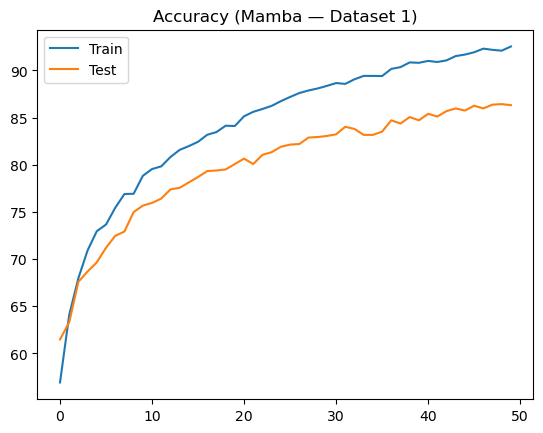

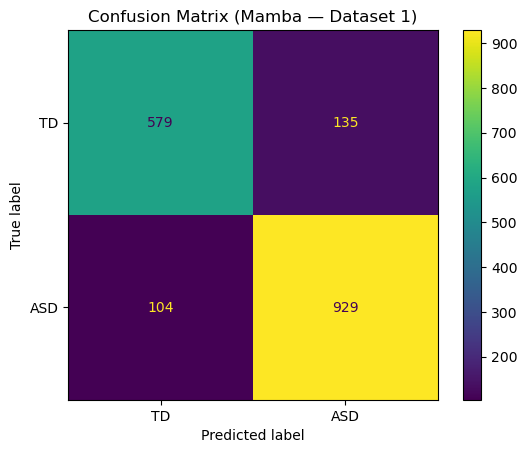

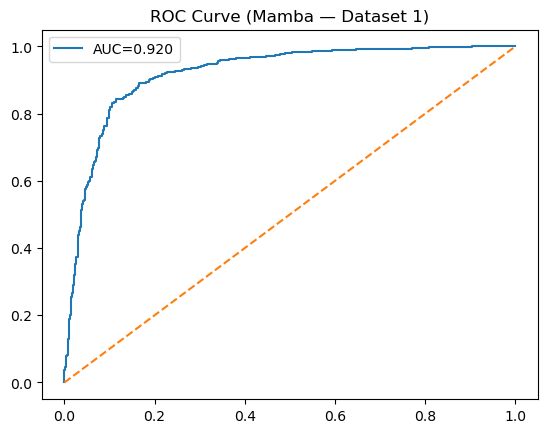

In [3]:
# ==============================
# 📦 IMPORTS (self-contained)
# ==============================
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import math
import torch.nn.functional as F

# ── Fallback config if Cell 1 not run ──
try:
    _device = device
    _root_dir = root_dir
    _epochs = EPOCHS
    _batch_size = BATCH_SIZE
    _lr = LR
except NameError:
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _root_dir = "/content/drive/MyDrive/AUTISM_2026/dataset"
    _epochs = 50
    _batch_size = 32
    _lr = 1e-4

print(f"Using device: {_device}")

# Pure PyTorch Mamba (Teacher's exact implementation — DO NOT MODIFY)
class Mamba(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = d_model * expand
        self.dt_rank = math.ceil(self.d_model / 16)

        self.in_proj = nn.Linear(self.d_model, self.d_inner * 2, bias=False)

        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            kernel_size=self.d_conv,
            bias=True,
            groups=self.d_inner,
            padding=self.d_conv - 1
        )

        self.x_proj = nn.Linear(self.d_inner, self.dt_rank + self.d_state * 2, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True)

        A = torch.arange(1, self.d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log = nn.Parameter(torch.log(A))
        self.D = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, self.d_model, bias=False)

    def forward(self, x):
        B, L, _ = x.shape
        projected = self.in_proj(x)
        x, z = projected.chunk(2, dim=-1)

        x = x.transpose(-1, -2)
        x = self.conv1d(x)[:, :, :L]
        x = x.transpose(-1, -2)
        x = F.silu(x)

        x_dbl = self.x_proj(x)
        dt, B_ssm, C_ssm = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt))
        A = -torch.exp(self.A_log.float())

        h = torch.zeros(B, self.d_inner, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for l in range(L):
            dt_l = dt[:, l, :].unsqueeze(-1)
            B_l = B_ssm[:, l, :].unsqueeze(1)
            C_l = C_ssm[:, l, :].unsqueeze(1)
            x_l = x[:, l, :].unsqueeze(-1)
            dA = torch.exp(dt_l * A.unsqueeze(0))
            dB = dt_l @ B_l
            h = dA * h + dB * x_l
            y_l = (h @ C_l.transpose(-1, -2)).squeeze(-1)
            ys.append(y_l)

        y = torch.stack(ys, dim=1)
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)
        y = y * F.silu(z)
        return self.out_proj(y)

# ==============================
# ⚙️ SETTINGS
# ==============================
window_size = 256

# ==============================
# 📦 DATASET
# ==============================
class EEGDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        self.labels = []
        class_map = {"ASD":1, "TD":0}
        print("📂 Loading dataset...")
        for cls, label in class_map.items():
            path = os.path.join(root_dir, cls)
            if not os.path.exists(path):
                print(f"❌ Missing: {path}")
                continue
            for file in os.listdir(path):
                if not file.endswith(".csv"): continue
                df = pd.read_csv(os.path.join(path, file))
                if 'subject' not in df.columns:
                    continue
                data = df.drop(columns=['subject', 'event']).values
                n = len(data) // window_size
                if n == 0:
                    continue
                data = data[:n * window_size]
                data = data.reshape(n, window_size, -1)
                data = np.transpose(data, (0, 2, 1))  # (N, 64, 256)
                for seg in data:
                    self.data.append(seg)
                    self.labels.append(label)
        if len(self.data) == 0:
            raise ValueError("❌ No data found")
        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"✅ Total samples: {len(self.data)}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        x = (x - np.mean(x)) / (np.std(x) + 1e-6)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# ==============================
# 🧠 EEG MAMBA MODEL
# ==============================
class EEGMamba(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.input_proj = nn.Linear(64, d_model)
        self.mamba = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.input_proj(x)
        x = self.mamba(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.fc(x)

# ==============================
# 🚀 LOAD DATA
# ==============================
dataset = EEGDataset(_root_dir)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_ds, _batch_size, True)
test_loader = DataLoader(test_ds, _batch_size, False)
print(f"Train samples: {len(train_ds)}")
print(f"Test samples: {len(test_ds)}")

# ==============================
# 🚀 MODEL & TRAINING
# ==============================
model = EEGMamba().to(_device)
try:
    # model = torch.compile(model)
    print("⚡ torch.compile() enabled")
except Exception:
    print("ℹ️  torch.compile() not available, using standard model")
optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
criterion = nn.CrossEntropyLoss()

train_acc_list = []
test_acc_list = []

for epoch in range(_epochs):
    model.train()
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(_device), y.to(_device)
        out = model(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    train_acc = 100 * correct / total

    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(_device), y.to(_device)
            out = model(x)
            probs = torch.softmax(out, 1)[:, 1]
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc = 100 * correct / total

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

# ==============================
# 📊 PLOTS
# ==============================
plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Accuracy (Mamba — Dataset 1)")
plt.show()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["TD", "ASD"]).plot()
plt.title("Confusion Matrix (Mamba — Dataset 1)")
plt.show()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.title("ROC Curve (Mamba — Dataset 1)")
plt.show()

try:
    results["Mamba"] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
except NameError:
    results = {"Mamba": {"test_acc": test_acc_list[-1], "auc": roc_auc}}


## 🧠 Cell 3: Dataset 1 — EEG Transformer (Teacher's Logic Preserved)

Using device: cuda
📂 Loading dataset...
✅ Total samples: 8734
Epoch 1 | Train: 60.53% | Test: 66.46%
Epoch 2 | Train: 66.70% | Test: 65.94%
Epoch 3 | Train: 69.13% | Test: 71.27%
Epoch 4 | Train: 73.61% | Test: 73.10%
Epoch 5 | Train: 74.01% | Test: 64.80%
Epoch 6 | Train: 75.97% | Test: 75.44%
Epoch 7 | Train: 77.46% | Test: 74.18%
Epoch 8 | Train: 78.26% | Test: 74.64%
Epoch 9 | Train: 78.82% | Test: 78.02%
Epoch 10 | Train: 80.59% | Test: 78.82%
Epoch 11 | Train: 82.25% | Test: 76.76%
Epoch 12 | Train: 81.85% | Test: 80.37%
Epoch 13 | Train: 84.01% | Test: 77.85%
Epoch 14 | Train: 85.73% | Test: 80.25%
Epoch 15 | Train: 84.49% | Test: 79.45%
Epoch 16 | Train: 84.94% | Test: 82.77%
Epoch 17 | Train: 86.68% | Test: 82.26%
Epoch 18 | Train: 86.65% | Test: 83.00%
Epoch 19 | Train: 86.20% | Test: 82.31%
Epoch 20 | Train: 88.48% | Test: 82.26%
Epoch 21 | Train: 88.89% | Test: 82.88%
Epoch 22 | Train: 89.62% | Test: 75.96%
Epoch 23 | Train: 88.76% | Test: 79.85%
Epoch 24 | Train: 89.75% | 

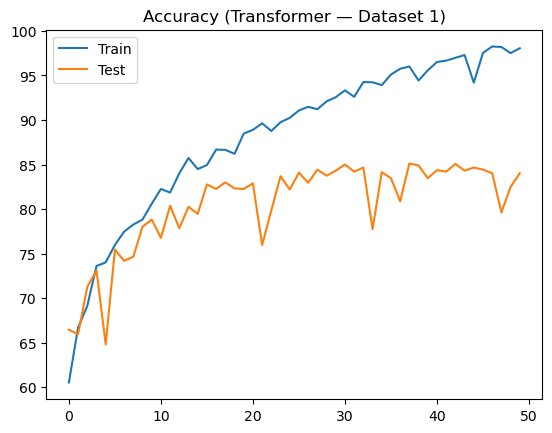

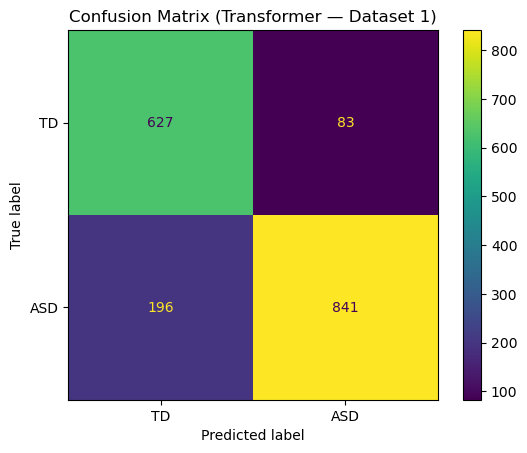

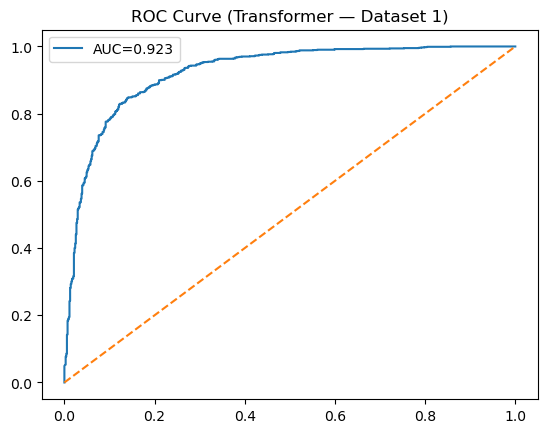

In [4]:
# ==============================
# 📦 IMPORTS (self-contained)
# ==============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import math
import torch.nn.functional as F

# ── Fallback config if Cell 1 not run ──
try:
    _device = device
    _root_dir = root_dir
    _epochs = EPOCHS
    _batch_size = BATCH_SIZE
    _lr = LR
except NameError:
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _root_dir = "/content/drive/MyDrive/AUTISM_2026/dataset"
    _epochs = 50
    _batch_size = 32
    _lr = 1e-4

print(f"Using device: {_device}")

# ==============================
# ⚙️ SETTINGS
# ==============================
window_size = 256

# ==============================
# 📦 DATASET
# ==============================
class EEGDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        self.labels = []
        class_map = {"ASD":1, "TD":0}
        print("📂 Loading dataset...")
        for cls, label in class_map.items():
            path = os.path.join(root_dir, cls)
            if not os.path.exists(path):
                print(f"❌ Missing: {path}")
                continue
            for file in os.listdir(path):
                if not file.endswith(".csv"): continue
                df = pd.read_csv(os.path.join(path, file))
                if 'subject' not in df.columns:
                    continue
                data = df.drop(columns=['subject', 'event']).values
                n = len(data) // window_size
                if n == 0:
                    continue
                data = data[:n * window_size]
                data = data.reshape(n, window_size, -1)
                data = np.transpose(data, (0, 2, 1))  # (N, 64, 256)
                for seg in data:
                    self.data.append(seg)
                    self.labels.append(label)
        if len(self.data) == 0:
            raise ValueError("❌ No data found")
        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"✅ Total samples: {len(self.data)}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        x = (x - np.mean(x)) / (np.std(x) + 1e-6)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# ==============================
# 🧠 TRANSFORMER MODEL
# ==============================
class EEGTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(64, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dropout=0.2, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)  # (B, 256, 64)
        x = self.input_proj(x)
        x = self.transformer(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.fc(x)

# ==============================
# 🚀 LOAD DATA
# ==============================
dataset = EEGDataset(_root_dir)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_ds, batch_size=_batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=_batch_size, shuffle=False)

# ==============================
# 🚀 MODEL SETUP
# ==============================
model = EEGTransformer().to(_device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# ==============================
# 🚀 TRAINING
# ==============================
train_acc_list = []
test_acc_list = []

for epoch in range(_epochs):
    model.train()
    correct, total = 0, 0
    for x, y in train_loader:
        x, y = x.to(_device), y.to(_device)
        out = model(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    train_acc = 100 * correct / total

    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    all_probs = []
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(_device), y.to(_device)
            out = model(x)
            probs = torch.softmax(out, 1)[:, 1]
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc = 100 * correct / total

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

# ==============================
# 📊 PLOTS
# ==============================
plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list, label="Test")
plt.legend()
plt.title("Accuracy (Transformer — Dataset 1)")
plt.show()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["TD", "ASD"]).plot()
plt.title("Confusion Matrix (Transformer — Dataset 1)")
plt.show()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.title("ROC Curve (Transformer — Dataset 1)")
plt.show()

try:
    results["Transformer"] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
except NameError:
    results = {"Transformer": {"test_acc": test_acc_list[-1], "auc": roc_auc}}

## 🧪 Cell 4: Dataset 1 — Baselines (1D-CNN, LSTM, GRU, CNN-LSTM)

Using device: cuda
📂 Loading dataset...
✅ Total samples: 8734
Train: 6987 | Test: 1747
[1D-CNN] Epoch 1 | Train: 58.34% | Test: 60.56%
[1D-CNN] Epoch 2 | Train: 59.37% | Test: 60.56%
[1D-CNN] Epoch 3 | Train: 60.20% | Test: 64.57%
[1D-CNN] Epoch 4 | Train: 66.75% | Test: 68.57%
[1D-CNN] Epoch 5 | Train: 70.07% | Test: 70.18%
[1D-CNN] Epoch 6 | Train: 72.38% | Test: 71.55%
[1D-CNN] Epoch 7 | Train: 73.35% | Test: 71.27%
[1D-CNN] Epoch 8 | Train: 74.75% | Test: 72.18%
[1D-CNN] Epoch 9 | Train: 74.92% | Test: 72.64%
[1D-CNN] Epoch 10 | Train: 76.83% | Test: 75.27%
[1D-CNN] Epoch 11 | Train: 77.50% | Test: 75.10%
[1D-CNN] Epoch 12 | Train: 78.76% | Test: 76.59%
[1D-CNN] Epoch 13 | Train: 79.20% | Test: 74.99%
[1D-CNN] Epoch 14 | Train: 80.09% | Test: 77.45%
[1D-CNN] Epoch 15 | Train: 81.31% | Test: 76.53%
[1D-CNN] Epoch 16 | Train: 81.82% | Test: 78.88%
[1D-CNN] Epoch 17 | Train: 81.94% | Test: 78.53%
[1D-CNN] Epoch 18 | Train: 83.13% | Test: 79.79%
[1D-CNN] Epoch 19 | Train: 83.03% | Test

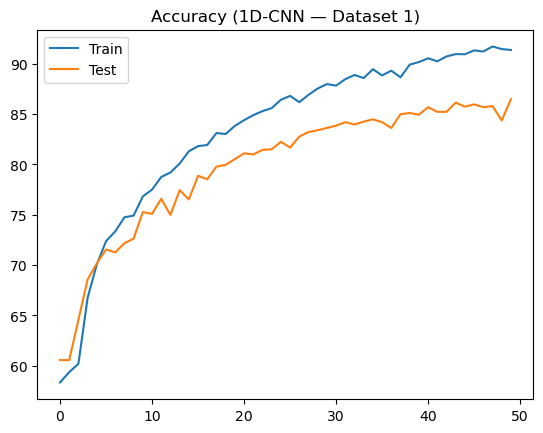

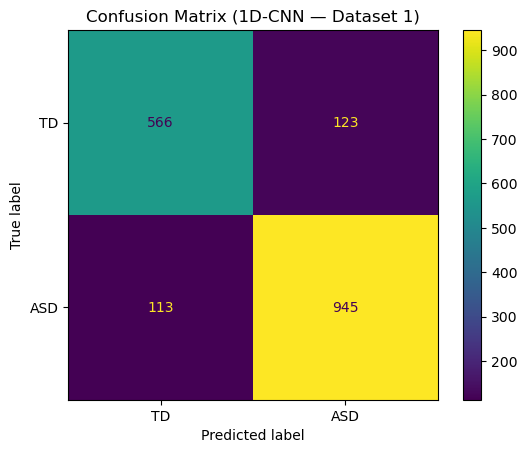

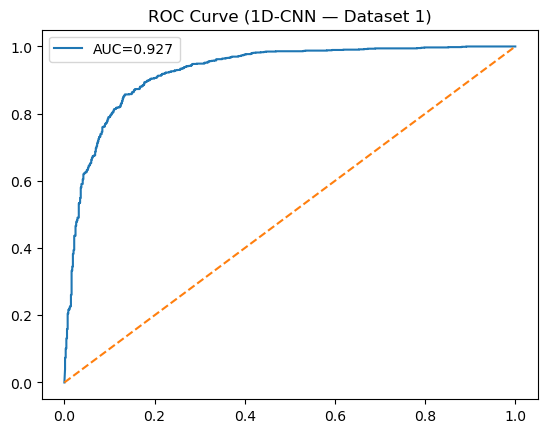

[LSTM] Epoch 1 | Train: 50.57% | Test: 60.62%
[LSTM] Epoch 2 | Train: 59.41% | Test: 60.56%
[LSTM] Epoch 3 | Train: 59.40% | Test: 60.62%
[LSTM] Epoch 4 | Train: 59.85% | Test: 61.88%
[LSTM] Epoch 5 | Train: 64.78% | Test: 68.12%
[LSTM] Epoch 6 | Train: 69.23% | Test: 69.20%
[LSTM] Epoch 7 | Train: 70.67% | Test: 70.12%
[LSTM] Epoch 8 | Train: 71.12% | Test: 69.03%
[LSTM] Epoch 9 | Train: 72.63% | Test: 70.86%
[LSTM] Epoch 10 | Train: 73.59% | Test: 70.06%
[LSTM] Epoch 11 | Train: 74.35% | Test: 70.69%
[LSTM] Epoch 12 | Train: 75.13% | Test: 72.30%
[LSTM] Epoch 13 | Train: 75.96% | Test: 72.98%
[LSTM] Epoch 14 | Train: 76.48% | Test: 74.41%
[LSTM] Epoch 15 | Train: 77.00% | Test: 75.04%
[LSTM] Epoch 16 | Train: 78.10% | Test: 75.73%
[LSTM] Epoch 17 | Train: 78.57% | Test: 76.70%
[LSTM] Epoch 18 | Train: 79.03% | Test: 75.21%
[LSTM] Epoch 19 | Train: 79.89% | Test: 75.16%
[LSTM] Epoch 20 | Train: 80.42% | Test: 76.42%
[LSTM] Epoch 21 | Train: 80.96% | Test: 76.59%
[LSTM] Epoch 22 | Trai

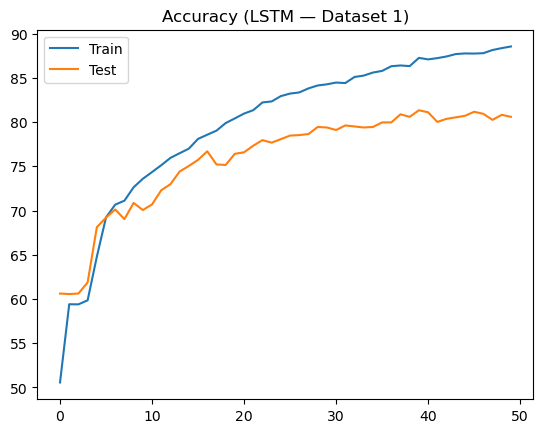

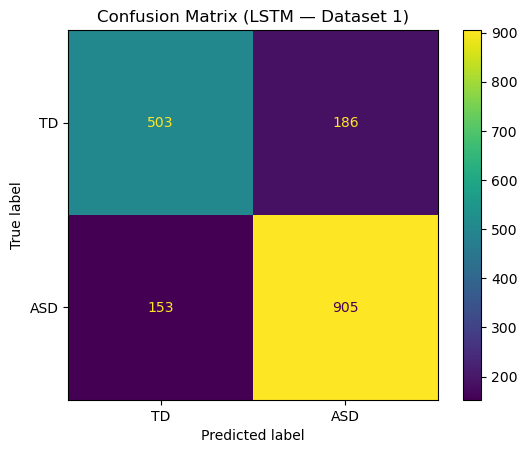

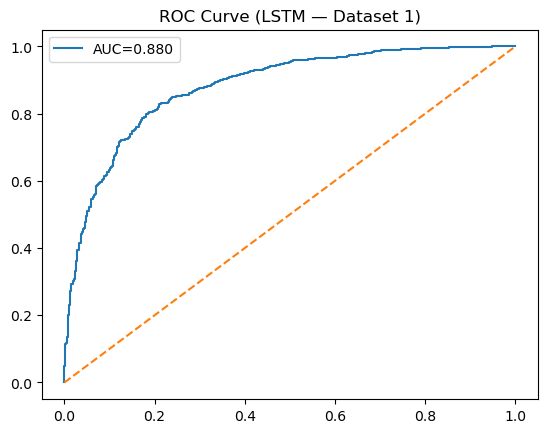

[GRU] Epoch 1 | Train: 57.62% | Test: 60.45%
[GRU] Epoch 2 | Train: 59.35% | Test: 60.50%
[GRU] Epoch 3 | Train: 59.37% | Test: 60.50%
[GRU] Epoch 4 | Train: 59.35% | Test: 60.56%
[GRU] Epoch 5 | Train: 59.98% | Test: 61.93%
[GRU] Epoch 6 | Train: 63.32% | Test: 64.91%
[GRU] Epoch 7 | Train: 66.39% | Test: 67.89%
[GRU] Epoch 8 | Train: 67.84% | Test: 68.46%
[GRU] Epoch 9 | Train: 69.54% | Test: 69.03%
[GRU] Epoch 10 | Train: 70.73% | Test: 70.01%
[GRU] Epoch 11 | Train: 72.02% | Test: 71.21%
[GRU] Epoch 12 | Train: 72.79% | Test: 71.61%
[GRU] Epoch 13 | Train: 73.88% | Test: 72.75%
[GRU] Epoch 14 | Train: 74.48% | Test: 72.47%
[GRU] Epoch 15 | Train: 75.54% | Test: 74.01%
[GRU] Epoch 16 | Train: 76.57% | Test: 74.24%
[GRU] Epoch 17 | Train: 77.40% | Test: 74.13%
[GRU] Epoch 18 | Train: 77.90% | Test: 74.30%
[GRU] Epoch 19 | Train: 78.32% | Test: 75.16%
[GRU] Epoch 20 | Train: 78.77% | Test: 76.70%
[GRU] Epoch 21 | Train: 79.73% | Test: 77.05%
[GRU] Epoch 22 | Train: 80.01% | Test: 78.5

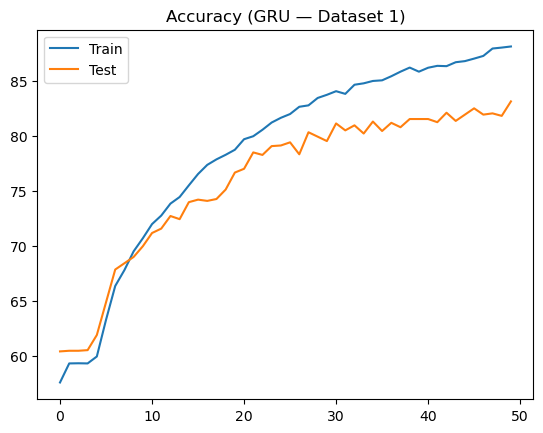

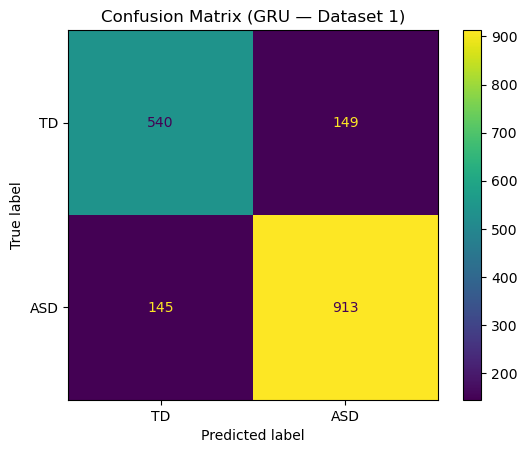

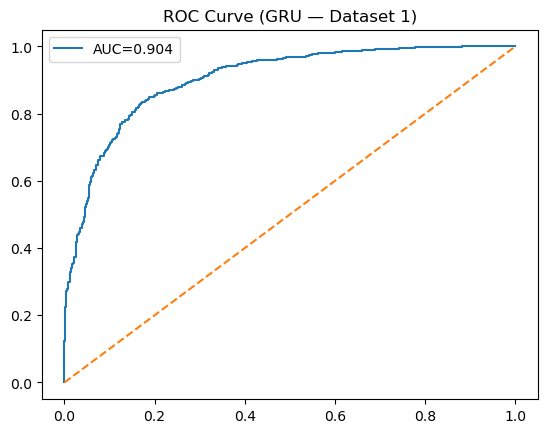

[CNN-LSTM] Epoch 1 | Train: 59.10% | Test: 60.56%
[CNN-LSTM] Epoch 2 | Train: 59.41% | Test: 60.79%
[CNN-LSTM] Epoch 3 | Train: 61.39% | Test: 66.00%
[CNN-LSTM] Epoch 4 | Train: 68.10% | Test: 69.20%
[CNN-LSTM] Epoch 5 | Train: 71.26% | Test: 72.12%
[CNN-LSTM] Epoch 6 | Train: 73.51% | Test: 73.84%
[CNN-LSTM] Epoch 7 | Train: 75.23% | Test: 73.15%
[CNN-LSTM] Epoch 8 | Train: 76.71% | Test: 75.96%
[CNN-LSTM] Epoch 9 | Train: 78.46% | Test: 75.96%
[CNN-LSTM] Epoch 10 | Train: 79.03% | Test: 77.79%
[CNN-LSTM] Epoch 11 | Train: 80.12% | Test: 77.16%
[CNN-LSTM] Epoch 12 | Train: 81.02% | Test: 77.50%
[CNN-LSTM] Epoch 13 | Train: 81.75% | Test: 78.31%
[CNN-LSTM] Epoch 14 | Train: 82.55% | Test: 78.71%
[CNN-LSTM] Epoch 15 | Train: 83.37% | Test: 79.51%
[CNN-LSTM] Epoch 16 | Train: 84.50% | Test: 79.34%
[CNN-LSTM] Epoch 17 | Train: 84.17% | Test: 80.02%
[CNN-LSTM] Epoch 18 | Train: 85.06% | Test: 80.31%
[CNN-LSTM] Epoch 19 | Train: 85.60% | Test: 80.82%
[CNN-LSTM] Epoch 20 | Train: 86.06% | Te

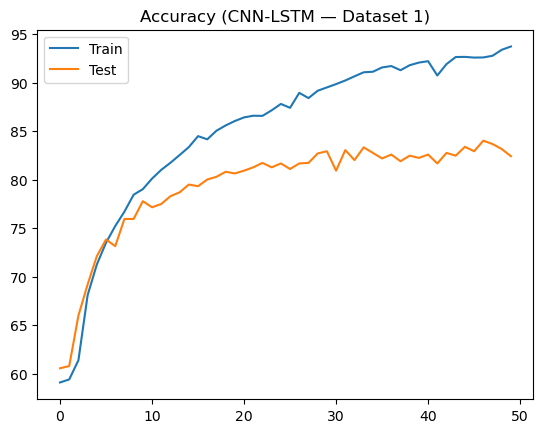

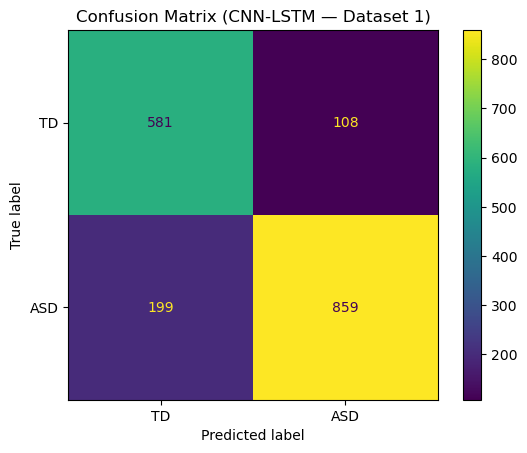

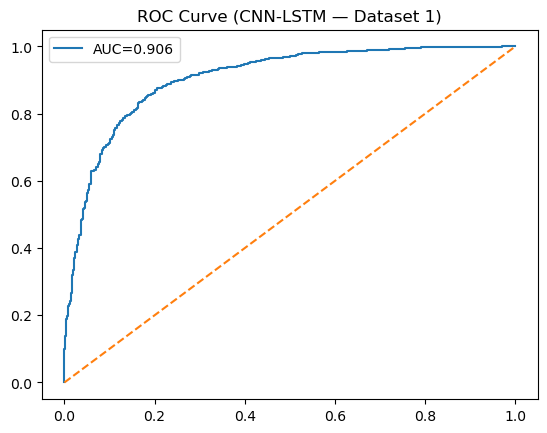

In [5]:
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

try:
    _device = device
    _root_dir = root_dir
    _epochs = EPOCHS
    _batch_size = BATCH_SIZE
    _lr = LR
except NameError:
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _root_dir = "/content/drive/MyDrive/AUTISM_2026/dataset"
    _epochs = 50
    _batch_size = 32
    _lr = 1e-4

print(f"Using device: {_device}")
window_size = 256

# ── Dataset ──
class EEGDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        self.labels = []
        class_map = {"ASD":1, "TD":0}
        print("📂 Loading dataset...")
        for cls, label in class_map.items():
            path = os.path.join(root_dir, cls)
            if not os.path.exists(path):
                print(f"❌ Missing: {path}")
                continue
            for file in os.listdir(path):
                if not file.endswith(".csv"): continue
                df = pd.read_csv(os.path.join(path, file))
                if 'subject' not in df.columns:
                    continue
                data = df.drop(columns=['subject', 'event']).values
                n = len(data) // window_size
                if n == 0:
                    continue
                data = data[:n * window_size]
                data = data.reshape(n, window_size, -1)
                data = np.transpose(data, (0, 2, 1))
                for seg in data:
                    self.data.append(seg)
                    self.labels.append(label)
        if len(self.data) == 0:
            raise ValueError("❌ No data found")
        self.data = np.array(self.data)
        self.labels = np.array(self.labels)
        print(f"✅ Total samples: {len(self.data)}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]
        x = (x - np.mean(x)) / (np.std(x) + 1e-6)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

# ── Models ──
class Simple1DCNN(nn.Module):
    def __init__(self, in_channels=64, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.net(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=64, hidden_size=64, num_layers=2, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out.mean(dim=1)
        return self.fc(out)

class SimpleGRU(nn.Module):
    def __init__(self, input_size=64, hidden_size=64, num_layers=2, num_classes=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)
        out = out.mean(dim=1)
        return self.fc(out)

class CNNLSTMHybrid(nn.Module):
    def __init__(self, in_channels=64, hidden_size=64, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(64, hidden_size, num_layers=1, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out.mean(dim=1)
        return self.fc(out)

# ── Load Data ──
dataset = EEGDataset(_root_dir)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_ds, test_ds = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_ds, _batch_size, True)
test_loader = DataLoader(test_ds, _batch_size, False)
print(f"Train: {len(train_ds)} | Test: {len(test_ds)}")

# ── Train Helper ──
def run_training(model, name):
    model = model.to(_device)
    optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
    criterion = nn.CrossEntropyLoss()
    train_acc_list, test_acc_list = [], []

    for epoch in range(_epochs):
        model.train()
        correct, total = 0, 0
        for x, y in train_loader:
            x, y = x.to(_device), y.to(_device)
            out = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            pred = out.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
        train_acc = 100 * correct / total

        model.eval()
        correct, total = 0, 0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(_device), y.to(_device)
                out = model(x)
                probs = torch.softmax(out, 1)[:, 1]
                pred = out.argmax(1)
                correct += (pred == y).sum().item()
                total += y.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        test_acc = 100 * correct / total
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f"[{name}] Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

    # Plots
    plt.plot(train_acc_list, label="Train")
    plt.plot(test_acc_list, label="Test")
    plt.legend()
    plt.title(f"Accuracy ({name} — Dataset 1)")
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=["TD", "ASD"]).plot()
    plt.title(f"Confusion Matrix ({name} — Dataset 1)")
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.legend()
    plt.title(f"ROC Curve ({name} — Dataset 1)")
    plt.show()

    try:
        results[name] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
    except NameError:
        pass
    return train_acc_list, test_acc_list

# ── Run All ──
ablation_models = {
    "1D-CNN": Simple1DCNN(),
    "LSTM": SimpleLSTM(),
    "GRU": SimpleGRU(),
    "CNN-LSTM": CNNLSTMHybrid(),
}
for name, m in ablation_models.items():
    run_training(m, name)

## 📊 Cell 5: Dataset 1 — Overall Comparison


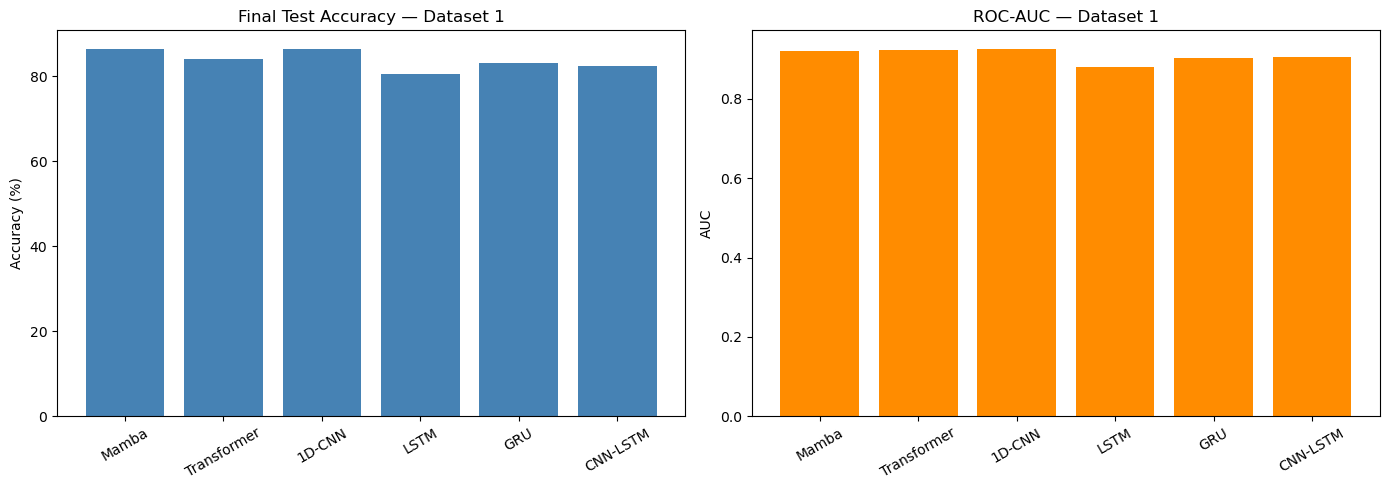

              test_acc       auc
Mamba        86.319405  0.920084
Transformer  84.029765  0.923093
1D-CNN       86.491128  0.926543
LSTM         80.595306  0.880360
GRU          83.171151  0.903689
CNN-LSTM     82.427018  0.905815


In [6]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    _results = results
except NameError:
    _results = {}

if len(_results) == 0:
    print("⚠️  No results found. Run previous cells first.")
else:
    names = list(_results.keys())
    accs = [_results[n]["test_acc"] for n in names]
    aucs = [_results[n]["auc"] for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(names, accs, color="steelblue")
    axes[0].set_title("Final Test Accuracy — Dataset 1")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(names, aucs, color="darkorange")
    axes[1].set_title("ROC-AUC — Dataset 1")
    axes[1].set_ylabel("AUC")
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    comparison_df = pd.DataFrame(_results).T
    print(comparison_df)

## 📦 Cell 6: Dataset 3 — Preprocessing & Setup (M-CHAT, 8-channel CSV, ASD vs Control)

In [7]:
import os
import math
import numpy as np
import pandas as pd
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Fallback config if Cell 1 not run ──
try:
    _device = device
    _epochs = EPOCHS
    _batch_size = BATCH_SIZE
    _lr = LR
    _d_model = D_MODEL
    _d_state = D_STATE
    _d_conv = D_CONV
    _expand = EXPAND
except NameError:
    _device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _epochs = 50
    _batch_size = 32
    _lr = 1e-4
    _d_model = 64
    _d_state = 16
    _d_conv = 4
    _expand = 2

print(f"Using device: {_device}")

# ── Path Auto-Detection (Colab Hosted / Colab Local / Pure Local) ──
try:
    from google.colab import drive
    _in_colab = True
    print("🔵 Google Colab detected")
    if not os.path.exists('/content/drive'):
        try:
            drive.mount('/content/drive')
        except Exception as e:
            print(f"   ⚠️ Drive mount skipped: {e}")

    # Try multiple Drive paths for Dataset 3
    mchat_drive_paths = [
        '/content/drive/MyDrive/AUTISM_2026/mchat-dataset',
        '/content/drive/MyDrive/mchat-dataset',
        '/content/drive/MyDrive/ASD vs TD EEG Classification/mchat-dataset',
    ]
    _mchat_dir = None
    for p in mchat_drive_paths:
        if os.path.exists(p):
            _mchat_dir = p
            print(f"✅ Dataset 3 found: {_mchat_dir}")
            break
    if _mchat_dir is None:
        _mchat_dir = '/content/drive/MyDrive/AUTISM_2026/mchat-dataset'
        print(f"⚠️  Dataset 3 not found, defaulting to: {_mchat_dir}")

except ImportError:
    _in_colab = False
    print("🟢 Local runtime detected")
    mchat_local_paths = [
        r'e:\ASD vs TD EEG Classification\mchat-dataset',
        r'e:/ASD vs TD EEG Classification/mchat-dataset',
    ]
    _mchat_dir = None
    for p in mchat_local_paths:
        if os.path.exists(p):
            _mchat_dir = p
            print(f"✅ Dataset 3 found: {_mchat_dir}")
            break
    if _mchat_dir is None:
        _mchat_dir = './mchat-dataset'
        print(f"⚠️  Dataset 3 not found, defaulting to: {_mchat_dir}")

# ── Dataset 3 paths ──
_asd_eeg_dir  = os.path.join(_mchat_dir, "Raw ASD Data",     "EEG Data")
_ctrl_eeg_dir = os.path.join(_mchat_dir, "Raw Control Data", "EEG Data")

print(f"\n📂 ASD  EEG Dir: {_asd_eeg_dir}")
print(f"📂 CTRL EEG Dir: {_ctrl_eeg_dir}")
print(f"📂 ASD  dir exists: {os.path.exists(_asd_eeg_dir)}")
print(f"📂 CTRL dir exists: {os.path.exists(_ctrl_eeg_dir)}")

# ── Dataset constants ──
D3_N_CHANNELS  = 8
D3_WINDOW_SIZE = 256   # same window as Dataset 1/2 for fair comparison
D3_SAT_VALUE   = -8388608  # 24-bit ADC lower rail (disconnected electrode)
D3_MIN_ROWS    = D3_WINDOW_SIZE  # discard subjects with fewer rows than one window

# ── Preprocessing helper: load one subject CSV ──
def load_mchat_subject(filepath):
    """
    Loads a single M-CHAT subject CSV.
    Handles:
      - Schema drift: ASD_Subject_14 uses columns 0-7 instead of 1-8.
      - Sensor saturation: channels stuck at -8388608 are linearly interpolated
        from neighbours (or zeroed if all channels are constant).
    Returns a float32 numpy array of shape (rows, 8).
    """
    df = pd.read_csv(filepath)
    # ── Schema standardisation ──
    cols = df.columns.tolist()
    if cols[0] == '0':                    # 0-indexed file (ASD_Subject_14)
        df.columns = [str(i + 1) for i in range(len(cols))]
    # Keep only channels 1-8
    ch_cols = [str(i) for i in range(1, D3_N_CHANNELS + 1)]
    df = df[ch_cols]
    data = df.values.astype(np.float64)

    # ── Sensor saturation masking ──
    for c in range(data.shape[1]):
        if np.all(data[:, c] == D3_SAT_VALUE) or np.std(data[:, c]) == 0:
            # Replace constant channel with mean of neighbours
            left  = (c - 1) % D3_N_CHANNELS
            right = (c + 1) % D3_N_CHANNELS
            if np.std(data[:, left]) > 0 and np.std(data[:, right]) > 0:
                data[:, c] = (data[:, left] + data[:, right]) / 2.0
            elif np.std(data[:, left]) > 0:
                data[:, c] = data[:, left]
            elif np.std(data[:, right]) > 0:
                data[:, c] = data[:, right]
            else:
                data[:, c] = 0.0

    return data.astype(np.float32)

# ── Dataset 3 PyTorch Dataset ──
class MChaTEEGDataset(Dataset):
    """
    Loads raw M-CHAT 8-channel CSVs for ASD (label=1) and Control (label=0).
    Applies:
      - Short-recording exclusion (< D3_MIN_ROWS samples)
      - Schema standardisation
      - Sensor saturation interpolation
      - Subject-wise, channel-wise Z-score normalisation
      - Sliding window segmentation (D3_WINDOW_SIZE)
    Output shape per sample: (8, D3_WINDOW_SIZE)
    """
    def __init__(self, asd_dir, ctrl_dir):
        self.data   = []
        self.labels = []
        class_dirs  = [(asd_dir, 1), (ctrl_dir, 0)]
        print("📂 Loading Dataset 3 (M-CHAT)...")
        for dirpath, label in class_dirs:
            if not os.path.exists(dirpath):
                print(f"❌ Missing: {dirpath}")
                continue
            files = sorted([f for f in os.listdir(dirpath)
                            if f.endswith('.csv') and 'Info' not in f])
            for fname in files:
                fpath = os.path.join(dirpath, fname)
                raw = load_mchat_subject(fpath)
                # ── Short-recording exclusion ──
                if len(raw) < D3_MIN_ROWS:
                    print(f"  ⚠️  Skipping {fname} ({len(raw)} rows < {D3_MIN_ROWS})")
                    continue
                # ── Subject-wise, channel-wise Z-score ──
                mu  = raw.mean(axis=0, keepdims=True)   # (1, 8)
                std = raw.std(axis=0,  keepdims=True) + 1e-6
                raw = (raw - mu) / std
                # ── Sliding-window segmentation ──
                n_windows = len(raw) // D3_WINDOW_SIZE
                raw = raw[:n_windows * D3_WINDOW_SIZE]
                raw = raw.reshape(n_windows, D3_WINDOW_SIZE, D3_N_CHANNELS)
                raw = np.transpose(raw, (0, 2, 1))  # (N, 8, 256)
                for seg in raw:
                    self.data.append(seg)
                    self.labels.append(label)
        if len(self.data) == 0:
            raise ValueError("❌ No data found — check _asd_eeg_dir / _ctrl_eeg_dir")
        self.data   = np.array(self.data,   dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.int64)
        asd_count  = int(self.labels.sum())
        ctrl_count = len(self.labels) - asd_count
        print(f"✅ Total segments: {len(self.data)} | ASD: {asd_count} | CTRL: {ctrl_count}")

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        return (torch.tensor(self.data[idx],   dtype=torch.float32),
                torch.tensor(self.labels[idx], dtype=torch.long))

# ── Load Dataset 3 ──
d3_dataset = MChaTEEGDataset(_asd_eeg_dir, _ctrl_eeg_dir)
d3_train_size = int(0.8 * len(d3_dataset))
d3_test_size  = len(d3_dataset) - d3_train_size
d3_train_ds, d3_test_ds = random_split(d3_dataset, [d3_train_size, d3_test_size])
d3_train_loader = DataLoader(d3_train_ds, batch_size=_batch_size, shuffle=True)
d3_test_loader  = DataLoader(d3_test_ds,  batch_size=_batch_size, shuffle=False)
print(f"📦 Train: {len(d3_train_ds)} | Test: {len(d3_test_ds)}")

# Results storage for Dataset 3
results_dataset3 = {}

Using device: cuda
🟢 Local runtime detected
✅ Dataset 3 found: e:\ASD vs TD EEG Classification\mchat-dataset

📂 ASD  EEG Dir: e:\ASD vs TD EEG Classification\mchat-dataset\Raw ASD Data\EEG Data
📂 CTRL EEG Dir: e:\ASD vs TD EEG Classification\mchat-dataset\Raw Control Data\EEG Data
📂 ASD  dir exists: True
📂 CTRL dir exists: True
📂 Loading Dataset 3 (M-CHAT)...
  ⚠️  Skipping ASD_Subject_04.csv (76 rows < 256)
  ⚠️  Skipping CTRL_Subject_08.csv (97 rows < 256)
✅ Total segments: 2182 | ASD: 1017 | CTRL: 1165
📦 Train: 1745 | Test: 437


## 🧠 Cell 7: Dataset 3 — EEG Mamba


Using device: cuda
Epoch 1 | Train: 56.91% | Test: 64.07%
Epoch 2 | Train: 62.98% | Test: 66.13%
Epoch 3 | Train: 65.56% | Test: 67.73%
Epoch 4 | Train: 67.45% | Test: 67.73%
Epoch 5 | Train: 68.77% | Test: 70.48%
Epoch 6 | Train: 69.34% | Test: 69.11%
Epoch 7 | Train: 70.43% | Test: 70.71%
Epoch 8 | Train: 72.09% | Test: 71.17%
Epoch 9 | Train: 72.72% | Test: 71.62%
Epoch 10 | Train: 72.78% | Test: 73.00%
Epoch 11 | Train: 74.27% | Test: 73.46%
Epoch 12 | Train: 75.01% | Test: 74.37%
Epoch 13 | Train: 76.22% | Test: 76.43%
Epoch 14 | Train: 76.91% | Test: 77.12%
Epoch 15 | Train: 78.28% | Test: 78.49%
Epoch 16 | Train: 78.57% | Test: 81.24%
Epoch 17 | Train: 79.71% | Test: 81.92%
Epoch 18 | Train: 81.32% | Test: 82.38%
Epoch 19 | Train: 82.01% | Test: 83.98%
Epoch 20 | Train: 83.27% | Test: 84.90%
Epoch 21 | Train: 84.64% | Test: 85.13%
Epoch 22 | Train: 84.99% | Test: 85.81%
Epoch 23 | Train: 86.02% | Test: 85.81%
Epoch 24 | Train: 86.36% | Test: 86.27%
Epoch 25 | Train: 86.93% | Tes

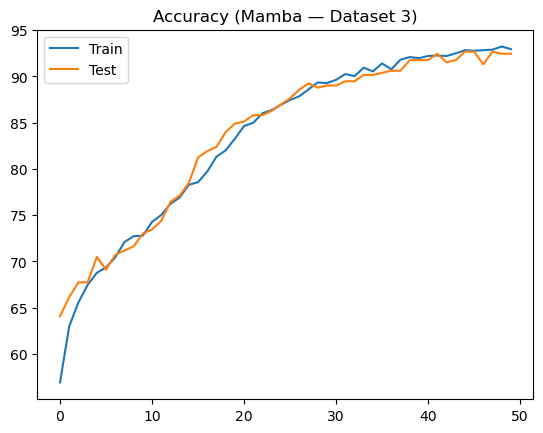

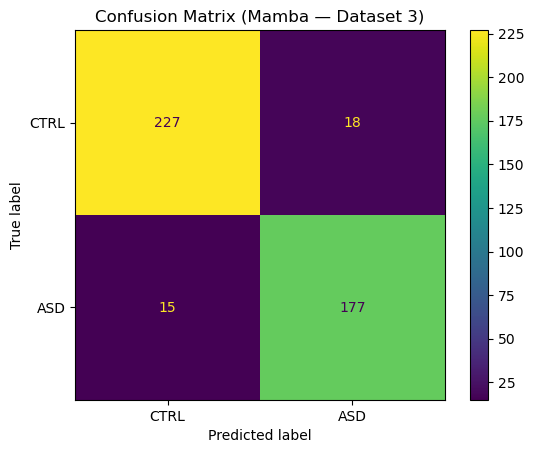

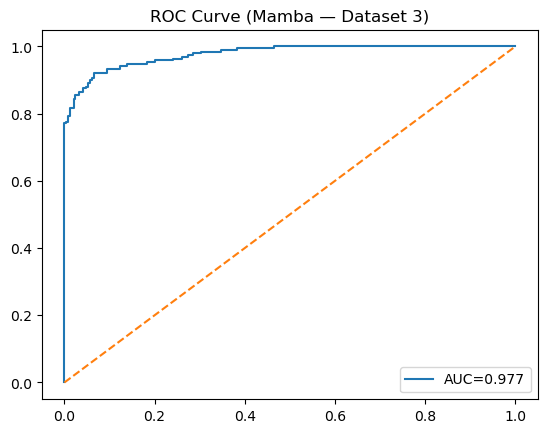

In [8]:
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Fallback config if Cell 1 not run ──
try:
    _device       = device
    _epochs       = EPOCHS
    _lr           = LR
    _d_model      = D_MODEL
    _d_state      = D_STATE
    _d_conv       = D_CONV
    _expand       = EXPAND
    _train_loader = d3_train_loader
    _test_loader  = d3_test_loader
except NameError:
    _device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _epochs  = 50
    _batch_size = 32
    _lr      = 1e-4
    _d_model = 64
    _d_state = 16
    _d_conv  = 4
    _expand  = 2
    print("⚠️  Run Cell 14 first to load Dataset 3")

print(f"Using device: {_device}")

# ── Mamba Block (same as teacher's) ──
class Mamba(nn.Module):
    def __init__(self, d_model, d_state=16, d_conv=4, expand=2):
        super().__init__()
        self.d_model  = d_model
        self.d_state  = d_state
        self.d_conv   = d_conv
        self.expand   = expand
        self.d_inner  = d_model * expand
        self.dt_rank  = math.ceil(self.d_model / 16)
        self.in_proj  = nn.Linear(self.d_model, self.d_inner * 2, bias=False)
        self.conv1d   = nn.Conv1d(self.d_inner, self.d_inner, self.d_conv, bias=True, groups=self.d_inner, padding=self.d_conv - 1)
        self.x_proj   = nn.Linear(self.d_inner, self.dt_rank + self.d_state * 2, bias=False)
        self.dt_proj  = nn.Linear(self.dt_rank, self.d_inner, bias=True)
        A = torch.arange(1, self.d_state + 1, dtype=torch.float32).repeat(self.d_inner, 1)
        self.A_log    = nn.Parameter(torch.log(A))
        self.D        = nn.Parameter(torch.ones(self.d_inner))
        self.out_proj = nn.Linear(self.d_inner, self.d_model, bias=False)

    def forward(self, x):
        B, L, _ = x.shape
        projected = self.in_proj(x)
        x, z = projected.chunk(2, dim=-1)
        x = x.transpose(-1, -2)
        x = self.conv1d(x)[:, :, :L]
        x = x.transpose(-1, -2)
        x = F.silu(x)
        x_dbl = self.x_proj(x)
        dt, B_ssm, C_ssm = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        dt = F.softplus(self.dt_proj(dt))
        A  = -torch.exp(self.A_log.float())
        h  = torch.zeros(B, self.d_inner, self.d_state, device=x.device, dtype=x.dtype)
        ys = []
        for l in range(L):
            dt_l = dt[:, l, :].unsqueeze(-1)
            B_l  = B_ssm[:, l, :].unsqueeze(1)
            C_l  = C_ssm[:, l, :].unsqueeze(1)
            x_l  = x[:, l, :].unsqueeze(-1)
            dA   = torch.exp(dt_l * A.unsqueeze(0))
            dB   = dt_l @ B_l
            h    = dA * h + dB * x_l
            y_l  = (h @ C_l.transpose(-1, -2)).squeeze(-1)
            ys.append(y_l)
        y = torch.stack(ys, dim=1)
        y = y + x * self.D.unsqueeze(0).unsqueeze(0)
        y = y * F.silu(z)
        return self.out_proj(y)

# ── EEG Mamba for 8 channels ──
class EEGMamba(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.input_proj = nn.Linear(8, d_model)
        self.mamba      = Mamba(d_model=d_model, d_state=_d_state, d_conv=_d_conv, expand=_expand)
        self.norm       = nn.LayerNorm(d_model)
        self.fc         = nn.Linear(d_model, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.input_proj(x)
        x = self.mamba(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.fc(x)

# ── Train ──
model     = EEGMamba().to(_device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
criterion = nn.CrossEntropyLoss()

train_acc_list, test_acc_list     = [], []
all_preds, all_labels, all_probs  = [], [], []

for epoch in range(_epochs):
    model.train()
    correct, total = 0, 0
    for x, y in _train_loader:
        x, y = x.to(_device), y.to(_device)
        out  = model(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pred     = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    train_acc = 100 * correct / total

    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in _test_loader:
            x, y  = x.to(_device), y.to(_device)
            out   = model(x)
            probs = torch.softmax(out, 1)[:, 1]
            pred  = out.argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc = 100 * correct / total
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

# ── Plots ──
plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list,  label="Test")
plt.legend()
plt.title("Accuracy (Mamba — Dataset 3)")
plt.show()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["CTRL", "ASD"]).plot()
plt.title("Confusion Matrix (Mamba — Dataset 3)")
plt.show()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.title("ROC Curve (Mamba — Dataset 3)")
plt.show()

try:
    results_dataset3["Mamba"] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
except NameError:
    results_dataset3 = {"Mamba": {"test_acc": test_acc_list[-1], "auc": roc_auc}}

## 🧠 Cell 8: Dataset 3 — EEG Transformer

Using device: cuda
Epoch 1 | Train: 60.00% | Test: 70.25%
Epoch 2 | Train: 68.88% | Test: 72.08%
Epoch 3 | Train: 71.69% | Test: 75.51%
Epoch 4 | Train: 72.61% | Test: 78.03%
Epoch 5 | Train: 76.10% | Test: 80.78%
Epoch 6 | Train: 78.85% | Test: 82.61%
Epoch 7 | Train: 81.09% | Test: 82.84%
Epoch 8 | Train: 83.72% | Test: 84.67%
Epoch 9 | Train: 85.56% | Test: 87.41%
Epoch 10 | Train: 87.45% | Test: 88.33%
Epoch 11 | Train: 89.68% | Test: 89.47%
Epoch 12 | Train: 91.00% | Test: 90.62%
Epoch 13 | Train: 90.37% | Test: 91.30%
Epoch 14 | Train: 92.03% | Test: 92.22%
Epoch 15 | Train: 92.26% | Test: 91.99%
Epoch 16 | Train: 93.41% | Test: 92.45%
Epoch 17 | Train: 94.73% | Test: 92.45%
Epoch 18 | Train: 95.19% | Test: 92.91%
Epoch 19 | Train: 94.04% | Test: 91.99%
Epoch 20 | Train: 94.84% | Test: 94.28%
Epoch 21 | Train: 95.93% | Test: 94.28%
Epoch 22 | Train: 96.62% | Test: 94.05%
Epoch 23 | Train: 96.10% | Test: 94.28%
Epoch 24 | Train: 95.99% | Test: 94.97%
Epoch 25 | Train: 96.79% | Tes

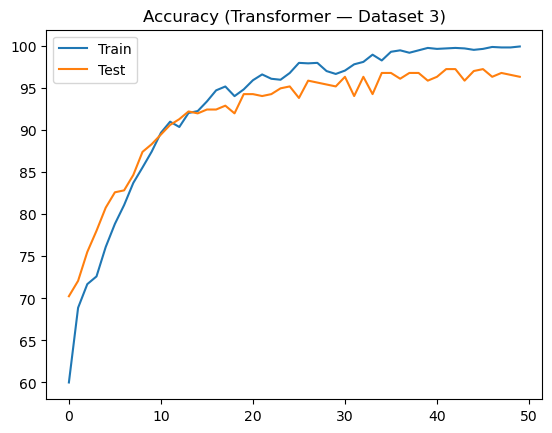

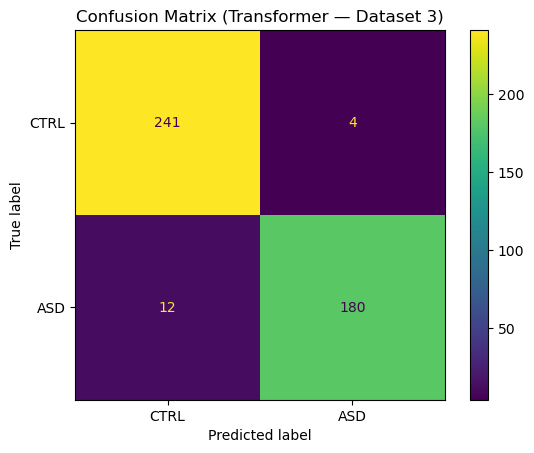

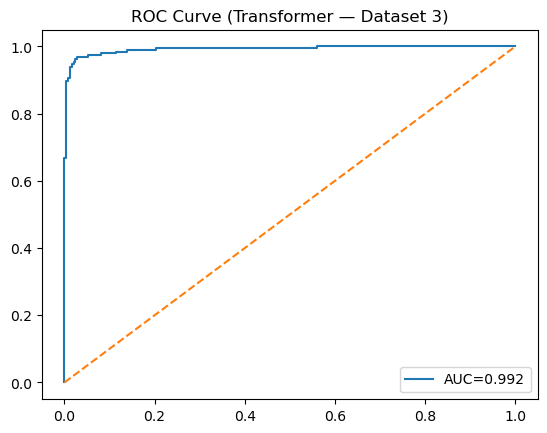

In [9]:
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Fallback config if Cell 1 not run ──
try:
    _device       = device
    _epochs       = EPOCHS
    _lr           = LR
    _d_model      = D_MODEL
    _train_loader = d3_train_loader
    _test_loader  = d3_test_loader
except NameError:
    _device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _epochs  = 50
    _batch_size = 32
    _lr      = 1e-4
    _d_model = 64
    print("⚠️  Run Cell 14 first to load Dataset 3")

print(f"Using device: {_device}")

class EEGTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=3):
        super().__init__()
        self.input_proj = nn.Linear(8, d_model)
        encoder_layer   = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dropout=0.2, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm        = nn.LayerNorm(d_model)
        self.fc          = nn.Linear(d_model, 2)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.input_proj(x)
        x = self.transformer(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.fc(x)

model     = EEGTransformer().to(_device)
optimizer = torch.optim.Adam(model.parameters(), lr=_lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_acc_list, test_acc_list    = [], []
all_preds, all_labels, all_probs = [], [], []

for epoch in range(_epochs):
    model.train()
    correct, total = 0, 0
    for x, y in _train_loader:
        x, y = x.to(_device), y.to(_device)
        out  = model(x)
        loss = criterion(out, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        pred     = out.argmax(1)
        correct += (pred == y).sum().item()
        total   += y.size(0)
    train_acc = 100 * correct / total

    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for x, y in _test_loader:
            x, y  = x.to(_device), y.to(_device)
            out   = model(x)
            probs = torch.softmax(out, 1)[:, 1]
            pred  = out.argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    test_acc = 100 * correct / total
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    print(f"Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

plt.plot(train_acc_list, label="Train")
plt.plot(test_acc_list,  label="Test")
plt.legend()
plt.title("Accuracy (Transformer — Dataset 3)")
plt.show()

cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=["CTRL", "ASD"]).plot()
plt.title("Confusion Matrix (Transformer — Dataset 3)")
plt.show()

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')
plt.legend()
plt.title("ROC Curve (Transformer — Dataset 3)")
plt.show()

try:
    results_dataset3["Transformer"] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
except NameError:
    results_dataset3 = {"Transformer": {"test_acc": test_acc_list[-1], "auc": roc_auc}}

## 🧪 Cell 9: Dataset 3 — Baselines (1D-CNN, LSTM, GRU, CNN-LSTM)

Using device: cuda
[1D-CNN] Epoch 1 | Train: 47.22% | Test: 46.68%
[1D-CNN] Epoch 2 | Train: 56.91% | Test: 60.64%
[1D-CNN] Epoch 3 | Train: 54.04% | Test: 54.46%
[1D-CNN] Epoch 4 | Train: 51.52% | Test: 56.29%
[1D-CNN] Epoch 5 | Train: 52.15% | Test: 56.52%
[1D-CNN] Epoch 6 | Train: 56.56% | Test: 65.22%
[1D-CNN] Epoch 7 | Train: 60.80% | Test: 67.05%
[1D-CNN] Epoch 8 | Train: 64.64% | Test: 67.73%
[1D-CNN] Epoch 9 | Train: 67.28% | Test: 69.11%
[1D-CNN] Epoch 10 | Train: 69.11% | Test: 69.11%
[1D-CNN] Epoch 11 | Train: 69.86% | Test: 67.28%
[1D-CNN] Epoch 12 | Train: 70.03% | Test: 68.19%
[1D-CNN] Epoch 13 | Train: 70.77% | Test: 68.19%
[1D-CNN] Epoch 14 | Train: 70.95% | Test: 69.34%
[1D-CNN] Epoch 15 | Train: 70.95% | Test: 71.40%
[1D-CNN] Epoch 16 | Train: 71.58% | Test: 70.71%
[1D-CNN] Epoch 17 | Train: 73.30% | Test: 72.77%
[1D-CNN] Epoch 18 | Train: 73.07% | Test: 74.14%
[1D-CNN] Epoch 19 | Train: 74.67% | Test: 75.06%
[1D-CNN] Epoch 20 | Train: 75.13% | Test: 78.26%
[1D-CNN] E

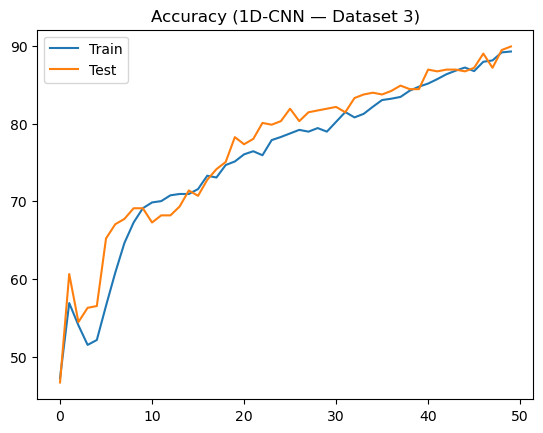

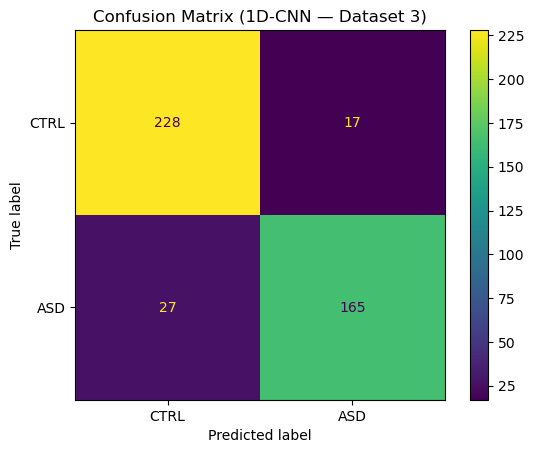

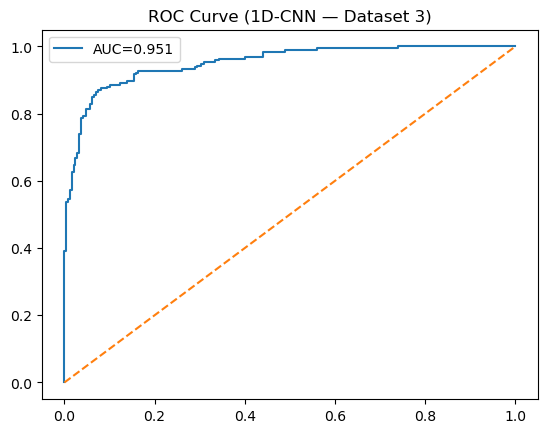

[LSTM] Epoch 1 | Train: 47.28% | Test: 43.71%
[LSTM] Epoch 2 | Train: 47.22% | Test: 44.16%
[LSTM] Epoch 3 | Train: 48.25% | Test: 45.08%
[LSTM] Epoch 4 | Train: 54.61% | Test: 56.75%
[LSTM] Epoch 5 | Train: 52.61% | Test: 56.52%
[LSTM] Epoch 6 | Train: 52.66% | Test: 56.29%
[LSTM] Epoch 7 | Train: 52.72% | Test: 56.06%
[LSTM] Epoch 8 | Train: 52.72% | Test: 56.06%
[LSTM] Epoch 9 | Train: 52.72% | Test: 56.06%
[LSTM] Epoch 10 | Train: 52.72% | Test: 56.29%
[LSTM] Epoch 11 | Train: 52.78% | Test: 56.52%
[LSTM] Epoch 12 | Train: 52.84% | Test: 56.52%
[LSTM] Epoch 13 | Train: 52.95% | Test: 56.98%
[LSTM] Epoch 14 | Train: 53.07% | Test: 56.98%
[LSTM] Epoch 15 | Train: 53.93% | Test: 58.58%
[LSTM] Epoch 16 | Train: 55.64% | Test: 59.95%
[LSTM] Epoch 17 | Train: 57.94% | Test: 66.59%
[LSTM] Epoch 18 | Train: 65.39% | Test: 69.34%
[LSTM] Epoch 19 | Train: 69.00% | Test: 67.73%
[LSTM] Epoch 20 | Train: 69.00% | Test: 67.96%
[LSTM] Epoch 21 | Train: 68.54% | Test: 67.96%
[LSTM] Epoch 22 | Trai

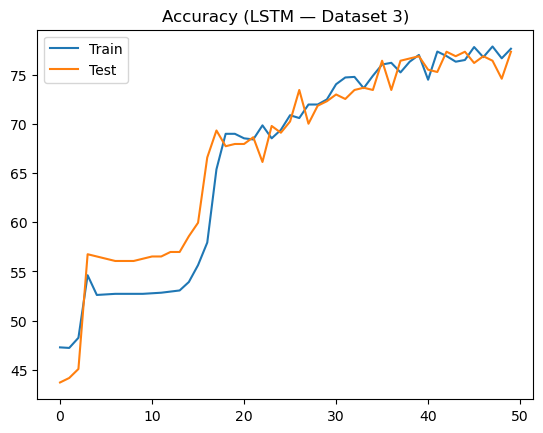

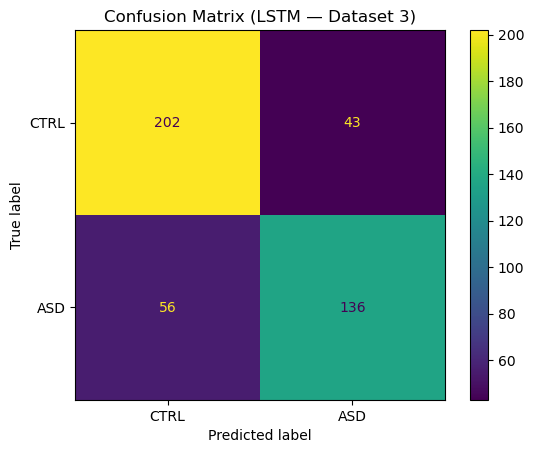

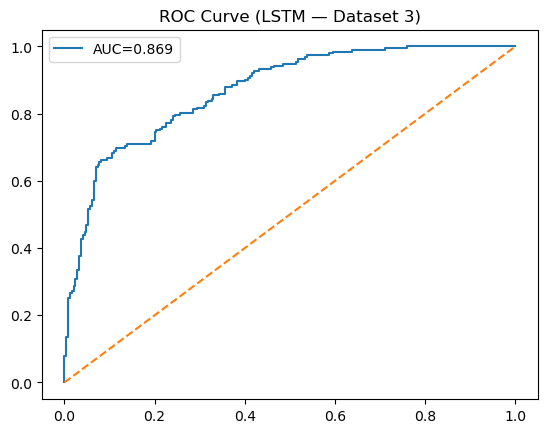

[GRU] Epoch 1 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 2 | Train: 52.66% | Test: 56.06%
[GRU] Epoch 3 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 4 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 5 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 6 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 7 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 8 | Train: 52.72% | Test: 56.06%
[GRU] Epoch 9 | Train: 53.01% | Test: 56.29%
[GRU] Epoch 10 | Train: 53.24% | Test: 56.29%
[GRU] Epoch 11 | Train: 53.35% | Test: 55.38%
[GRU] Epoch 12 | Train: 53.12% | Test: 55.38%
[GRU] Epoch 13 | Train: 53.24% | Test: 56.75%
[GRU] Epoch 14 | Train: 54.15% | Test: 58.12%
[GRU] Epoch 15 | Train: 55.30% | Test: 59.04%
[GRU] Epoch 16 | Train: 55.64% | Test: 59.27%
[GRU] Epoch 17 | Train: 55.87% | Test: 59.04%
[GRU] Epoch 18 | Train: 55.99% | Test: 62.01%
[GRU] Epoch 19 | Train: 58.80% | Test: 67.96%
[GRU] Epoch 20 | Train: 65.96% | Test: 63.16%
[GRU] Epoch 21 | Train: 66.59% | Test: 66.36%
[GRU] Epoch 22 | Train: 66.30% | Test: 65.2

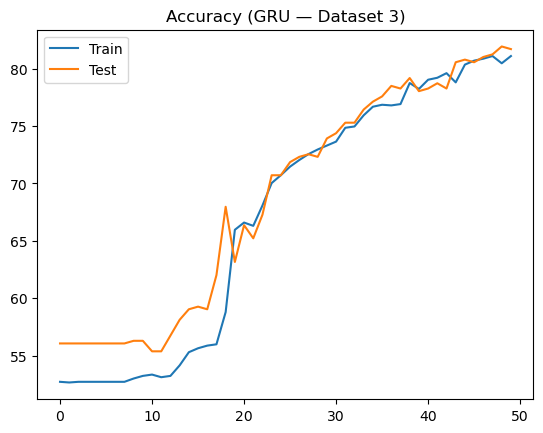

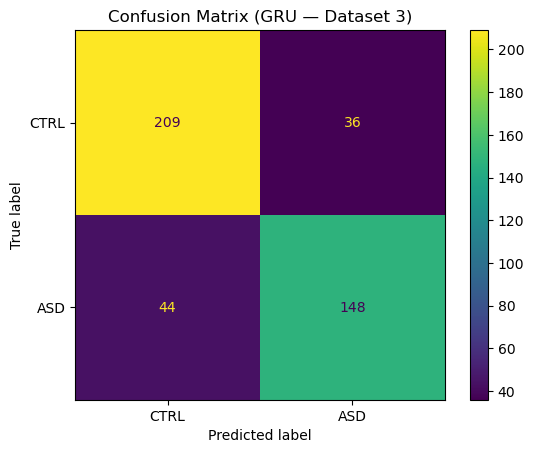

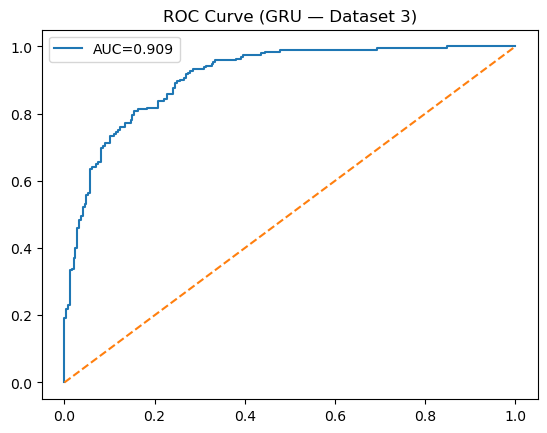

[CNN-LSTM] Epoch 1 | Train: 51.06% | Test: 57.21%
[CNN-LSTM] Epoch 2 | Train: 55.47% | Test: 57.67%
[CNN-LSTM] Epoch 3 | Train: 51.40% | Test: 56.52%
[CNN-LSTM] Epoch 4 | Train: 51.81% | Test: 56.29%
[CNN-LSTM] Epoch 5 | Train: 51.81% | Test: 56.52%
[CNN-LSTM] Epoch 6 | Train: 52.15% | Test: 56.52%
[CNN-LSTM] Epoch 7 | Train: 52.89% | Test: 57.89%
[CNN-LSTM] Epoch 8 | Train: 53.01% | Test: 58.35%
[CNN-LSTM] Epoch 9 | Train: 54.73% | Test: 62.70%
[CNN-LSTM] Epoch 10 | Train: 58.17% | Test: 65.22%
[CNN-LSTM] Epoch 11 | Train: 64.24% | Test: 70.25%
[CNN-LSTM] Epoch 12 | Train: 69.05% | Test: 70.71%
[CNN-LSTM] Epoch 13 | Train: 70.77% | Test: 69.11%
[CNN-LSTM] Epoch 14 | Train: 71.46% | Test: 70.02%
[CNN-LSTM] Epoch 15 | Train: 72.15% | Test: 72.77%
[CNN-LSTM] Epoch 16 | Train: 73.52% | Test: 73.46%
[CNN-LSTM] Epoch 17 | Train: 75.87% | Test: 75.29%
[CNN-LSTM] Epoch 18 | Train: 76.79% | Test: 78.26%
[CNN-LSTM] Epoch 19 | Train: 75.19% | Test: 77.57%
[CNN-LSTM] Epoch 20 | Train: 77.94% | Te

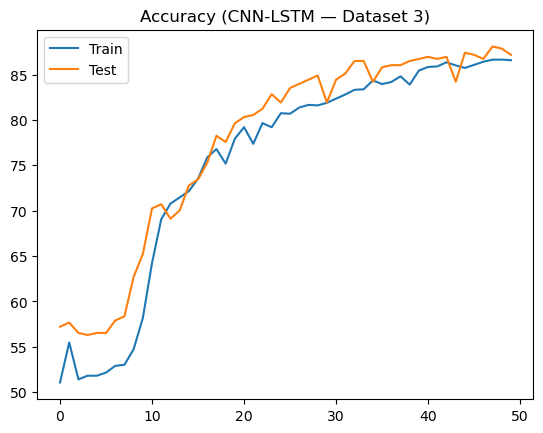

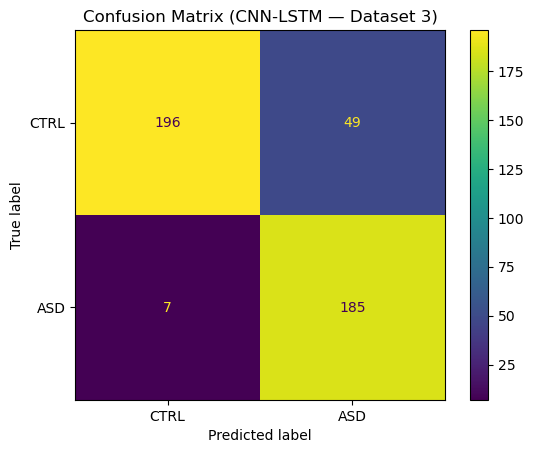

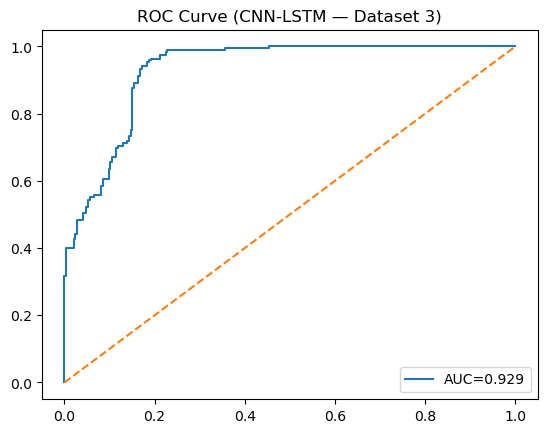

In [10]:
import torch
torch.set_float32_matmul_precision('high')
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# ── Fallback config if Cell 1 not run ──
try:
    _device       = device
    _epochs       = EPOCHS
    _lr           = LR
    _train_loader = d3_train_loader
    _test_loader  = d3_test_loader
except NameError:
    _device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _epochs  = 50
    _batch_size = 32
    _lr      = 1e-4
    print("⚠️  Run Cell 14 first to load Dataset 3")

print(f"Using device: {_device}")

class Simple1DCNN(nn.Module):
    def __init__(self, in_channels=8, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.net(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class SimpleLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, num_classes=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out.mean(dim=1)
        return self.fc(out)

class SimpleGRU(nn.Module):
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, num_classes=2):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc  = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        out, _ = self.gru(x)
        out = out.mean(dim=1)
        return self.fc(out)

class CNNLSTMHybrid(nn.Module):
    def __init__(self, in_channels=8, hidden_size=64, num_classes=2):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.ReLU(), nn.MaxPool1d(2),
        )
        self.lstm = nn.LSTM(64, hidden_size, num_layers=1, batch_first=True)
        self.fc   = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        out = out.mean(dim=1)
        return self.fc(out)

def run_training(model, name):
    model     = model.to(_device)
    optimizer = torch.optim.Adam(model.parameters(), lr=_lr)
    criterion = nn.CrossEntropyLoss()
    train_acc_list, test_acc_list = [], []

    for epoch in range(_epochs):
        model.train()
        correct, total = 0, 0
        for x, y in _train_loader:
            x, y = x.to(_device), y.to(_device)
            out  = model(x)
            loss = criterion(out, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            pred     = out.argmax(1)
            correct += (pred == y).sum().item()
            total   += y.size(0)
        train_acc = 100 * correct / total

        model.eval()
        correct, total = 0, 0
        all_preds, all_labels, all_probs = [], [], []
        with torch.no_grad():
            for x, y in _test_loader:
                x, y  = x.to(_device), y.to(_device)
                out   = model(x)
                probs = torch.softmax(out, 1)[:, 1]
                pred  = out.argmax(1)
                correct += (pred == y).sum().item()
                total   += y.size(0)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(y.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
        test_acc = 100 * correct / total
        train_acc_list.append(train_acc)
        test_acc_list.append(test_acc)
        print(f"[{name}] Epoch {epoch+1} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}%")

    plt.plot(train_acc_list, label="Train")
    plt.plot(test_acc_list,  label="Test")
    plt.legend()
    plt.title(f"Accuracy ({name} — Dataset 3)")
    plt.show()

    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels=["CTRL", "ASD"]).plot()
    plt.title(f"Confusion Matrix ({name} — Dataset 3)")
    plt.show()

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], '--')
    plt.legend()
    plt.title(f"ROC Curve ({name} — Dataset 3)")
    plt.show()

    try:
        results_dataset3[name] = {"test_acc": test_acc_list[-1], "auc": roc_auc}
    except NameError:
        pass
    return train_acc_list, test_acc_list

ablation_models = {
    "1D-CNN":   Simple1DCNN(),
    "LSTM":     SimpleLSTM(),
    "GRU":      SimpleGRU(),
    "CNN-LSTM": CNNLSTMHybrid(),
}
for name, m in ablation_models.items():
    run_training(m, name)

## 📊 Cell 10: Dataset 3 — Overall Comparison

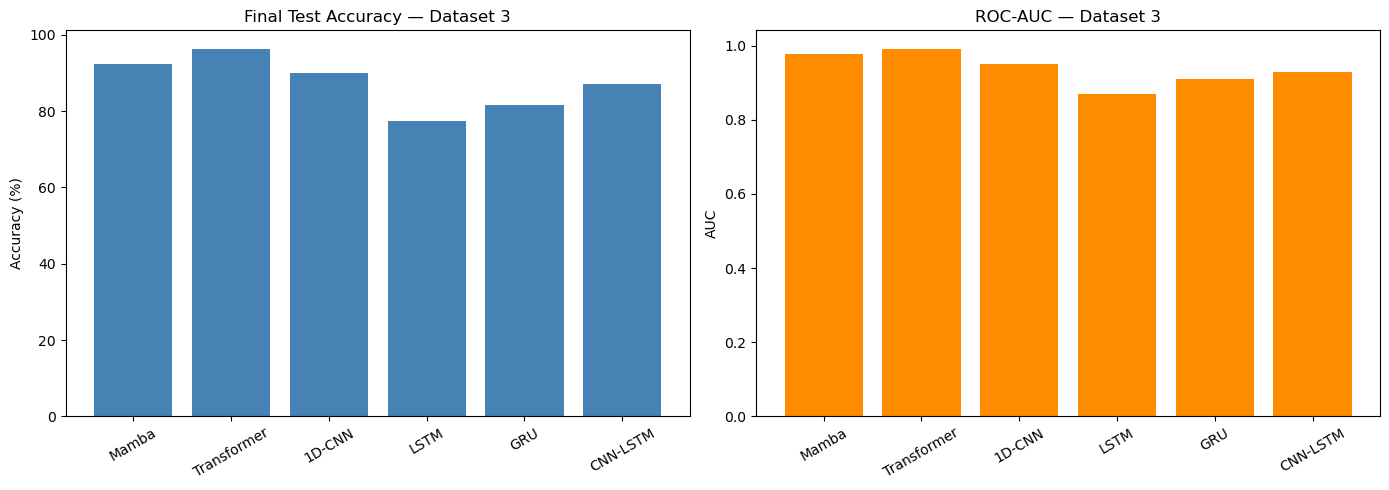

              test_acc       auc
Mamba        92.448513  0.976935
Transformer  96.338673  0.991922
1D-CNN       89.931350  0.951212
LSTM         77.345538  0.869154
GRU          81.693364  0.909375
CNN-LSTM     87.185355  0.929124


In [11]:
import matplotlib.pyplot as plt
import pandas as pd

try:
    _results = results_dataset3
except NameError:
    _results = {}

if len(_results) == 0:
    print("⚠️  No results found. Run previous Dataset 3 cells first.")
else:
    names = list(_results.keys())
    accs  = [_results[n]["test_acc"] for n in names]
    aucs  = [_results[n]["auc"]      for n in names]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(names, accs, color="steelblue")
    axes[0].set_title("Final Test Accuracy — Dataset 3")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].tick_params(axis='x', rotation=30)

    axes[1].bar(names, aucs, color="darkorange")
    axes[1].set_title("ROC-AUC — Dataset 3")
    axes[1].set_ylabel("AUC")
    axes[1].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

    comparison_df = pd.DataFrame(_results).T
    print(comparison_df)